In [3]:
# download_data.py
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)
df.to_csv("data.csv", index=False)
print("Downloaded dataset saved as data.csv")


Downloaded dataset saved as data.csv


  Using cached nbconvert-7.16.6-py3-none-any.whl.metadata (8.5 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached jupyter_events-0.12.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter_server_terminals-0.5.3-py3-none-any.whl.metadata (5.6 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached overrides-7.7.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached Send2Trash-1.8.3-py3-none-any.whl.metadata (4.0 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached babel-2.17.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached rfc3339_validator-0.1.4-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached rfc3986_validator-0.1.1-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached fqdn-1.5.1-py3-none-

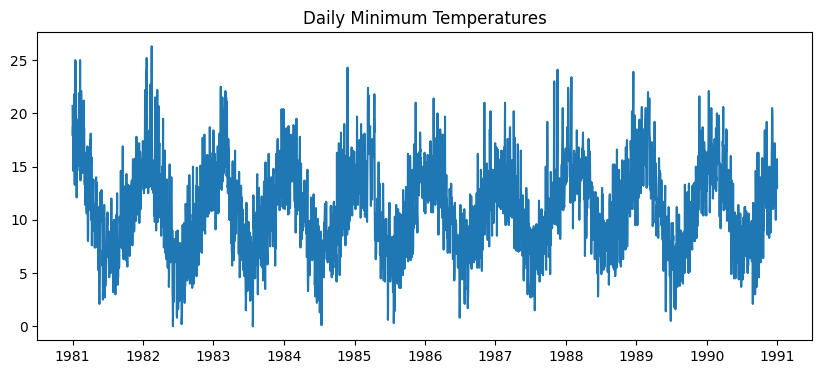


Differenced Series Stationarity:

ADF Statistic: -18.07006336121461
p-value: 2.6057827189281196e-30
Series is likely stationary.


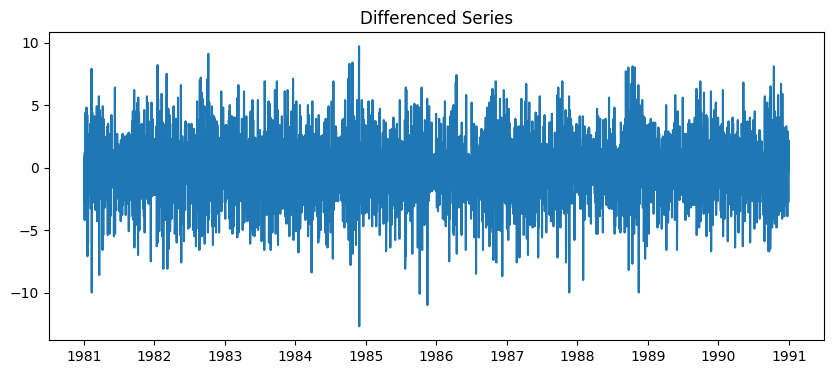

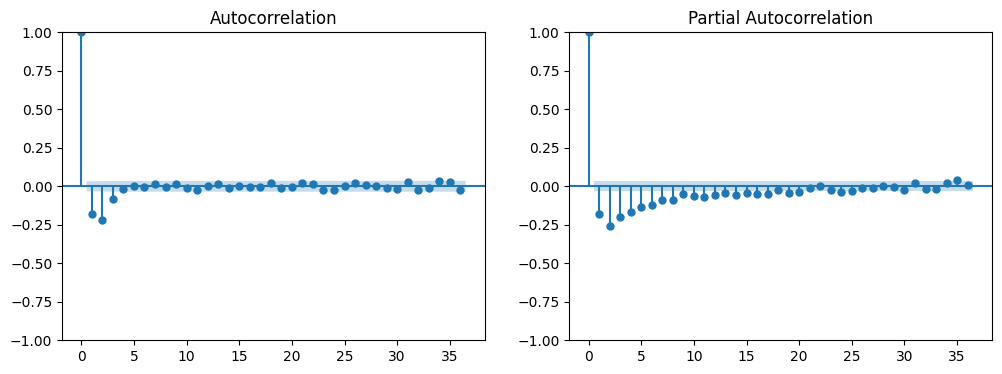

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3652
Model:                 ARIMA(5, 1, 1)   Log Likelihood               -8390.233
Date:                Fri, 28 Nov 2025   AIC                          16794.465
Time:                        11:17:08   BIC                          16837.884
Sample:                    01-01-1981   HQIC                         16809.928
                         - 12-31-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4959      0.021     24.056      0.000       0.456       0.536
ar.L2         -0.1305      0.019     -6.901      0.000      -0.168      -0.093
ar.L3          0.0020      0.019      0.102      0.9

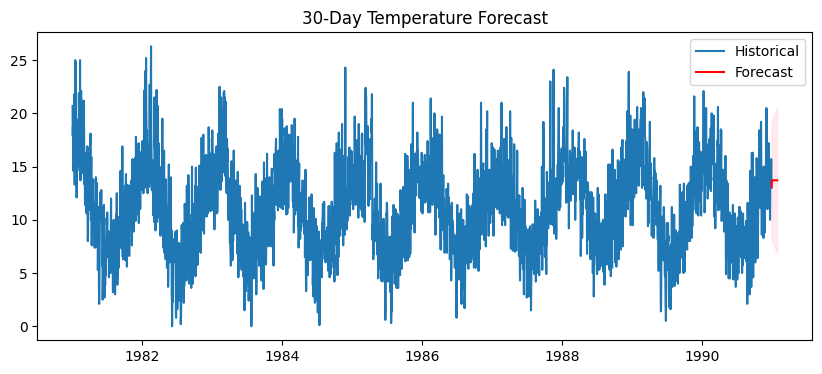


Forecast saved to forecast.csv


In [9]:
!pip install pandas numpy matplotlib statsmodels scipy jupyter


# forecast.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

warnings.filterwarnings("ignore")

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv("data.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")
ts = df["Temp"].asfreq("D")
ts = ts.fillna(method="ffill")

# ------------------------------
# Stationarity Check
# ------------------------------
def check_stationarity(series):
    result = adfuller(series.dropna())
    print("\nADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("Series is likely stationary.")
    else:
        print("Series is NOT stationary.")

print("Original Series Stationarity:")
check_stationarity(ts)

# ------------------------------
# Plot original series
# ------------------------------
plt.figure(figsize=(10, 4))
plt.plot(ts)
plt.title("Daily Minimum Temperatures")
plt.show()

# ------------------------------
# Create difference series (for ACF/PACF)
# ------------------------------
ts_diff = ts.diff().dropna()
print("\nDifferenced Series Stationarity:")
check_stationarity(ts_diff)

plt.figure(figsize=(10, 4))
plt.plot(ts_diff)
plt.title("Differenced Series")
plt.show()

# ------------------------------
# Plot ACF and PACF
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_diff, ax=axes[0])
plot_pacf(ts_diff, ax=axes[1])
plt.show()

# ------------------------------
# Fit ARIMA model
# ------------------------------
order = (5, 1, 1)  # safe ARIMA order for this dataset
model = ARIMA(ts, order=order)
res = model.fit()
print(res.summary())

# ------------------------------
# Forecast next 30 days
# ------------------------------
steps = 30
forecast = res.get_forecast(steps=steps)
pred_mean = forecast.predicted_mean
conf = forecast.conf_int()

# ------------------------------
# Plot forecast
# ------------------------------
plt.figure(figsize=(10, 4))
plt.plot(ts, label="Historical")
plt.plot(pred_mean, label="Forecast", color="red")
plt.fill_between(conf.index, conf.iloc[:, 0], conf.iloc[:, 1], color="pink", alpha=0.3)
plt.title("30-Day Temperature Forecast")
plt.legend()
plt.show()

# ------------------------------
# Save forecast
# ------------------------------
pred_mean.to_csv("forecast.csv")
print("\nForecast saved to forecast.csv")
